# Role Games — Simulation Notebook

Runs the N-player modified stag hunt under three conditions: **Anonymous**, **Identity**, **Tag-based**.

See `role_games/` for the underlying modules.

In [1]:
import sys
sys.path.insert(0, '.')

from role_games import Condition, run_multiple, run_all_conditions, to_dataframes, export_csv
from role_games.visualize import plot_summary, plot_outcome_proportions
import matplotlib.pyplot as plt
%matplotlib inline

## Parameters

In [54]:
N_PLAYERS        = 4     # 3, 4, or 5
REPLACEMENT_RATE = 0.2   # probability of replacing one agent each round
N_SIMULATIONS    = 200
N_ROUNDS         = 50
K_CONVERGENCE    = 5
TAU              = 0.01
BASE_SEED        = 42

---
## Single condition

In [ ]:
CONDITION = Condition.TAG_BASED   # Anonymous | Identity | Tag-based

round_records, summary_records = run_multiple(
    condition=CONDITION,
    n_simulations=N_SIMULATIONS,
    n_rounds=N_ROUNDS,
    k_convergence=K_CONVERGENCE,
    tau=TAU,
    n_players=N_PLAYERS,
    replacement_rate=REPLACEMENT_RATE,
    base_seed=BASE_SEED,
)

rounds_df, summary_df = to_dataframes(round_records, summary_records)
print(f"Rounds logged: {len(rounds_df):,}")
print(f"Replacements:  {rounds_df['replaced'].sum()}")
print(f"Rounds converged: {rounds_df.groupby('simulation_id')['converged'].any().sum()} / {N_SIMULATIONS} sims had at least one converged round")
rounds_df.head()

In [ ]:
fig = plot_summary(rounds_df)
plt.show()

---
## All three conditions

In [55]:
all_round_records, all_summary_records = run_all_conditions(
    n_simulations=N_SIMULATIONS,
    n_rounds=N_ROUNDS,
    k_convergence=K_CONVERGENCE,
    tau=TAU,
    n_players=N_PLAYERS,
    replacement_rate=REPLACEMENT_RATE,
    base_seed=BASE_SEED,
)

all_rounds_df, all_summary_df = to_dataframes(all_round_records, all_summary_records)

for cond, grp in all_rounds_df.groupby('condition'):
    trio = grp.groupby('simulation_id')['converged'].any()
    print(f"{cond:12s}  sims with converged round={trio.sum()}/{N_SIMULATIONS}  "
          f"mean_complexity={grp['complexity'].mean():.3f}")

Anonymous     sims with converged round=180/200  mean_complexity=0.928
Identity      sims with converged round=197/200  mean_complexity=0.709
Tag-based     sims with converged round=199/200  mean_complexity=0.685


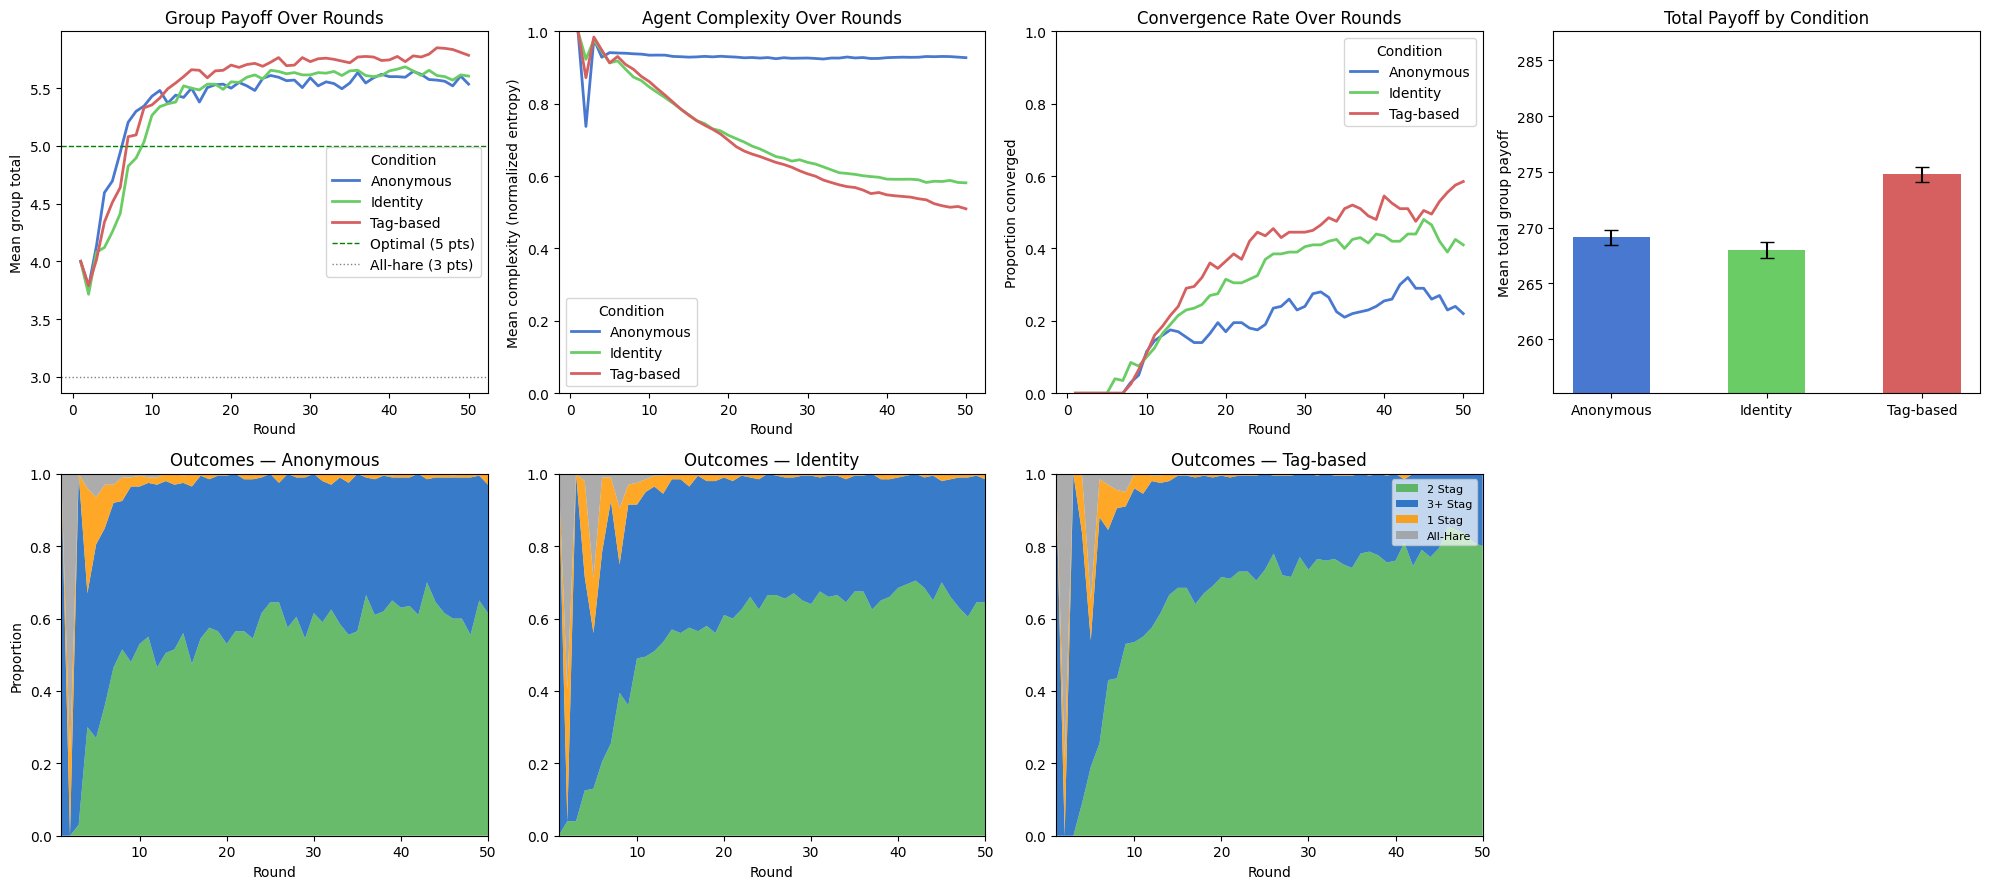

In [56]:
fig = plot_summary(all_rounds_df)
plt.show()

## Export to CSV

In [ ]:
# export_csv(all_rounds_df, all_summary_df, output_dir='data')